# Which metric exposes the default prior's failure? ROI vs. mROI

**The problem this notebook solves.** In this scenario the `default` prior's
`roi_m` estimate for TV misses the truth -- but only just, and its interval
nearly touches. That is a weak headline for a talk: a skeptic reasonably says
"your ROI is basically right." Meanwhile `ec_m` fails unambiguously in the same
fit. So the *mechanism* is clearly broken while the *headline business metric*
looks nearly fine.

**Why that happens, and why it is not a flaw to be fixed.** ROI at current
spend is structurally near-identified even when `ec_m` is badly wrong. In the
near-linear regime the response is approximately `beta * x / ec`, so the
likelihood pins the ratio `beta/ec` -- and ROI is precisely the response at
*observed* delivery divided by spend. The `beta`/`ec` ridge that makes `ec_m`
unidentifiable is the same ridge that leaves ROI at 1x intact. Trying to force
`roi_m` to fail harder would mean breaking the model in ways unrelated to
saturation. The right move is to report a metric that actually depends on the
part the model gets wrong.

**Why true `ec_m` is set to 9.0 here.** Meridian's default `ec_m` prior is
`TruncatedNormal(0.8, 0.8, [0.1, 10])` -- hard-truncated at 10. Earlier versions
of this scenario used a true `ec_m` of 11.069, which sits *outside* that
support, so the default prior assigned it exactly zero probability. That invites
a fair objection: "you picked a truth your opponent's prior forbids." Pinning
the truth at 9.0 puts it inside the stated support and removes the objection at
a cost of only a few points of headline error. Section 2 shows why this changes
little: the prior's *concentration*, not its truncation boundary, is the
mechanism.

**What this notebook establishes:**
- Section 4: `roi_m` is a weak discriminator, and **mROI at current spend is
  weaker still** -- the ROI and elasticity errors point opposite ways and partly
  cancel, so it can read as near-correct while the curve is badly wrong.
- Section 5: the same mROI evaluated at *elevated* spend is the sharpest
  discriminator available.
- Section 6: **the invariance result** -- move the true `ec_m` and the default
  fit barely follows, while the informed fit tracks it almost one-for-one. The
  default posterior is reporting its prior, not estimating the parameter.
- Section 7: a ranked recommendation for which number to lead with.

Numbers are deliberately **not** hardcoded into this prose -- every quoted
figure below comes from a printed cell output, so re-executing cannot leave the
narrative stale.

In [1]:
import os
import sys
import time

# This notebook lives in `demo/synthetic/final/`, but the study's helper
# modules (`data_simulator.py`, `model_utils.py`) and its `fitted_models/`
# artifact directory live one level up in `demo/synthetic/`. Resolve that
# directory explicitly rather than relying on the working directory, so the
# notebook runs identically from Jupyter, nbconvert, or Colab.
STUDY_DIR = next(
    d for d in (os.path.abspath(os.getcwd()),
                os.path.abspath(os.path.join(os.getcwd(), '..')))
    if os.path.exists(os.path.join(d, 'data_simulator.py')))
if STUDY_DIR not in sys.path:
  sys.path.insert(0, STUDY_DIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy import stats

from meridian.model import adstock_hill
from meridian.model import model
from meridian.analysis import analyzer

from data_simulator import SimulationConfig
from model_utils import build_comparison_table
from model_utils import build_model_spec
from model_utils import build_real_augmented_input

print('study dir:', STUDY_DIR)
OUT_DIR = os.path.join(STUDY_DIR, 'fitted_models', 'mroi_metric_selection')
os.makedirs(OUT_DIR, exist_ok=True)
VARIANTS = ['default', 'ec_alpha_only']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)
SIM_SEED = 0
MULTIPLIERS = [1, 2, 3, 5, 10]

# Section 5 needs two scenarios that differ ONLY in true ec_m.
PRIMARY, COMPARISON = 'ec9', 'ec11'

study dir: /Users/mariappan.subramanian/Documents/repo/meridian/demo/synthetic


## 1. Build the scenario at a chosen true `ec_m`

The Display-fixed scenario (audience 0.50, `Channel2`) with TV's
`adstock_retention_range` pinned to `(0.8, 0.8)`, plus one new control: TV's
true `ec_m` is *solved for* rather than left wherever the audience assumptions
happen to put it.

**How that solve works.** Working through
`simulate_adstock_hill_params()`, per-capita impressions are
`reach_frac * target_audience_pop_frac * frequency` and the half-saturation
point is `saturation_frequency * 0.5 * target_audience_pop_frac`, so

```
ec_m = saturation_frequency * 0.5 / median(reach_frac * frequency)
```

`target_audience_pop_frac` cancels entirely -- changing the audience size does
*not* move `ec_m`. `saturation_frequency` moves it linearly, and (unlike reach
or frequency) it leaves the channel's media execution completely untouched. So
we solve for the `saturation_frequency` that lands TV at each target `ec_m`,
and assert afterwards that impressions are bit-identical across the two
scenarios. That makes Section 5 a clean single-variable comparison.

Two consequences worth stating up front, because they are easy to misread:

- **Adstock weights are normalized** (`normalize=True` in
  `adstock_hill._adstock`), so raising alpha does *not* scale TV's media up, it
  smooths it. TV's position on its saturation curve is set by `ec_m` alone.
- **True `roi_m` differs between the two scenarios** because
  `roi_ec_elasticity=-0.3` ties ROI to `ec_m` by construction. Compare
  *relative* errors across scenarios, never absolute ROI levels.

In [2]:
BASE_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.50, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {'TV': (1, 2), 'Display': (1, 5), 'Social': (7.0, 8.0)},
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    'n_times': 156,
    'n_knots_mu_t': 8,
    'roi_ec_elasticity': -0.3,
    'roi_alpha_elasticity': 0.3,
    'adstock_retention_range': {
        'TV': (0.8, 0.8), 'Display': (0.0, 0.3), 'Social': (0.1, 0.4),
    },
}
TARGET_EC_M = {'ec9': 9.0, 'ec11': 11.069}

real_df = pd.read_csv(
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_media_rf.csv'
)


def build(saturation_frequency_tv=None):
  """Runs the simulator; `None` leaves `saturation_frequency` at its default."""
  overrides = dict(BASE_OVERRIDES)
  if saturation_frequency_tv is not None:
    overrides['saturation_frequency'] = {
        'TV': saturation_frequency_tv, 'Display': 4.0, 'Social': 4.0}
  np.random.seed(SIM_SEED)
  tf.random.set_seed(SIM_SEED)
  cfg = SimulationConfig.from_dict(overrides)
  sim, data, gt = build_real_augmented_input(
      cfg, real_df,
      rf_source_map={'TV': 'Channel3'},
      plain_source_map={'Display': 'Channel2', 'Social': 'Channel1'},
  )
  return cfg, sim, data, gt


# ec_m is linear in saturation_frequency, so one baseline run calibrates both.
_, sim_base, _, _ = build()
EC_BASE, SF_BASE = float(sim_base.ec_m.numpy()[0]), 4.0

scen = {}
for tag, target in TARGET_EC_M.items():
  sf = SF_BASE * target / EC_BASE
  cfg, sim, data, gt = build(sf)
  scen[tag] = dict(config=cfg, sim=sim, data=data, ground_truth=gt,
                   saturation_frequency=sf,
                   true_roi=np.asarray(gt['roi_m']),
                   true_ec=sim.ec_m.numpy(), true_alpha=sim.alpha_m.numpy())
  assert abs(float(sim.ec_m.numpy()[0]) - target) < 0.05, f'{tag}: ec_m solve missed'
  assert abs(float(sim.alpha_m.numpy()[0]) - 0.8) < 1e-6, f'{tag}: TV alpha != 0.8'

channels = list(scen[PRIMARY]['config'].channel_names)

# The whole point of using saturation_frequency as the knob: media is identical.
delta = np.abs(scen['ec9']['sim'].impression_gtm.numpy()
               - scen['ec11']['sim'].impression_gtm.numpy()).max()
assert delta == 0, f'media execution differs between scenarios ({delta})'

summary = pd.DataFrame([
    {'scenario': t,
     'saturation_frequency(TV)': round(s['saturation_frequency'], 4),
     **{f'true_ec_m[{c}]': round(float(s['true_ec'][i]), 3)
        for i, c in enumerate(channels)},
     **{f'true_roi_m[{c}]': round(float(s['true_roi'][i]), 3)
        for i, c in enumerate(channels)}}
    for t, s in scen.items()])
print('true alpha_m (both scenarios):',
      np.round(scen[PRIMARY]['true_alpha'], 3))
print('media execution identical across scenarios: max |diff| =', delta)
summary

I0000 00:00:1785279484.405983  342201 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [11.069365    1.3505481   0.29689494]
ec_m = [9.000001   1.3505481  0.29689494]


ec_m = [11.068999    1.3505481   0.29689494]
true alpha_m (both scenarios): [0.8   0.078 0.252]
media execution identical across scenarios: max |diff| = 0.0


,scenario,saturation_frequency(TV),true_ec_m[TV],true_ec_m[Display],true_ec_m[Social],true_roi_m[TV],true_roi_m[Display],true_roi_m[Social]
0,ec9,3.2522,9.000,1.351,0.297,6.66,3.664,4.918
1,ec11,3.9999,11.069,1.351,0.297,6.39,3.740,5.020


## 2. Where the truth sits inside the default prior

Before fitting anything: the default `ec_m` prior is
`TruncatedNormal(0.8, 0.8, [0.1, 10])`, and `ec_m` is expressed in multiples of
the channel's own median non-zero per-capita execution -- so `x = 1.0` means
"what you already run."

The table below places each channel's true `ec_m` inside that prior. The
mechanism the talk should lead with is **concentration, not truncation**: the
default puts the overwhelming majority of its mass at low `ec_m`, i.e. it
asserts *a priori* that no channel is far from half-saturation. Whether the
truth is 9.0 (inside the support) or 11.069 (outside it) barely matters, since
the prior density at either is negligible.

In [3]:
default_ec_prior = stats.truncnorm(
    a=(0.1 - 0.8) / 0.8, b=(10 - 0.8) / 0.8, loc=0.8, scale=0.8)

rows = []
for tag, s in scen.items():
  for i, ch in enumerate(channels):
    v = float(s['true_ec'][i])
    rows.append({'scenario': tag, 'channel': ch, 'true_ec_m': round(v, 3),
                 'inside_support': 0.1 <= v <= 10.0,
                 'prior_pctile': round(float(default_ec_prior.cdf(v)) * 100, 4),
                 'prior_density': f'{float(default_ec_prior.pdf(v)):.2e}'})
prior_placement = pd.DataFrame(rows).drop_duplicates(
    subset=['channel', 'true_ec_m']).reset_index(drop=True)

for q in (0.50, 0.95, 0.99):
  print(f'default prior: {q * 100:.0f}% of mass below ec_m = '
        f'{default_ec_prior.ppf(q):.3f}')
print(f'default prior: mass above ec_m = 4.0 is '
      f'{(1 - default_ec_prior.cdf(4.0)) * 100:.4f}%')
prior_placement

default prior: 50% of mass below ec_m = 0.993
default prior: 95% of mass below ec_m = 2.196
default prior: 99% of mass below ec_m = 2.724
default prior: mass above ec_m = 4.0 is 0.0039%


,scenario,channel,true_ec_m,inside_support,prior_pctile,prior_density
0,ec9,TV,9.000,True,100.0000,9.46e-24
1,ec9,Display,1.351,True,69.6411,4.86e-01
2,ec9,Social,0.297,True,9.1356,5.06e-01
3,ec11,TV,11.069,False,100.0000,0.00e+00


## 3. Fit both scenarios

`media_prior_type='roi'` for both variants -- **Meridian's own default**
(`ModelSpec().effective_media_prior_type` resolves to `'roi'` when left unset).

That choice is load-bearing for a talk about default settings. An earlier
version of this notebook used `'coefficient'`, which Meridian explicitly warns
against on every fit, and using a non-default parameterization while critiquing
defaults would have been a fair procedural objection. Switching to the real
default also *sharpens* every result rather than softening it: `ec_m` fails
harder and Section 5's discriminator roughly doubles. The reason follows
directly from the ridge argument in the header -- the ROI prior sits on the
*well-identified* direction, where the likelihood swamps it, which leaves `ec_m`
even more purely prior-determined than under `'coefficient'`.

`default` gets Meridian's priors untouched; `ec_alpha_only` gets
reach/frequency-informed `ec_m` and `alpha_m` priors built by
`model_utils.build_reach_based_ec_prior` / `build_alpha_prior` from the same
audience assumptions a media team could state.

This notebook fits its own models rather than loading previously saved ones.
That is deliberate: `save_mmm`/`load_mmm` use plain `joblib`, so a pickle is
only loadable by the same Meridian build that wrote it, and this repo has both
a system-installed `meridian` and the editable repo install available depending
on which interpreter runs. Fitting here keeps the models native to whatever
kernel executes the notebook. Four fits, roughly 9 minutes.

In [4]:
fitted = {}
for tag in (PRIMARY, COMPARISON):
  s = scen[tag]
  for variant in VARIANTS:
    t0 = time.time()
    model_spec = build_model_spec(
        variant, s['sim'], s['config'], media_prior_type='roi')
    mmm = model.Meridian(input_data=s['data'], model_spec=model_spec)
    mmm.sample_prior(500)
    mmm.sample_posterior(**MCMC_KWARGS)
    fitted[(tag, variant)] = mmm
    mmm.inference_data.to_netcdf(
        os.path.join(OUT_DIR, f'{tag}_{variant}_inference_data.nc'))
    print(f'{tag}/{variant}: {time.time() - t0:.0f}s', flush=True)

s = scen[PRIMARY]
comparison = build_comparison_table(
    {v: fitted[(PRIMARY, v)] for v in VARIANTS},
    s['config'], s['sim'], s['ground_truth'], hdi_prob=0.9)
comparison.to_csv(os.path.join(OUT_DIR, f'{PRIMARY}_comparison_table.csv'),
                  index=False)
print(f'\nparameter recovery -- {PRIMARY} (true TV ec_m = '
      f'{TARGET_EC_M[PRIMARY]})')
comparison

2026-07-28 17:58:29.049465: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


ec9/default: 138s


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


2026-07-28 18:00:48.445663: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


ec9/ec_alpha_only: 121s


...

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)



parameter recovery -- ec9 (true TV ec_m = 9.0)


,channel,param,true,default,ec_alpha_only
0,TV,alpha_m,0.800,0.806 (0.78-0.83) ✓,0.808 (0.78-0.83) ✓
1,TV,ec_m,9.000,2.842 (2.11-3.65) ✗,9.143 (7.59-10.63) ✓
2,TV,roi_m,6.660,7.573 (6.68-8.41) ✗,6.526 (5.85-7.14) ✓
3,Display,alpha_m,0.078,0.102 (0.07-0.14) ✓,0.109 (0.08-0.14) ✓
4,Display,ec_m,1.351,1.325 (1.03-1.61) ✓,1.346 (1.18-1.53) ✓
5,Display,roi_m,3.664,3.740 (3.41-4.05) ✓,3.768 (3.48-4.04) ✓
6,Social,alpha_m,0.252,0.237 (0.22-0.26) ✓,0.242 (0.22-0.26) ✓
7,Social,ec_m,0.297,0.300 (0.26-0.34) ✓,0.293 (0.26-0.33) ✓
8,Social,roi_m,4.918,4.737 (4.27-5.19) ✓,4.850 (4.42-5.19) ✓


## 4. The two metrics that do not work

`Analyzer.roi()` and `Analyzer.marginal_roi()` both evaluate at the historical
spend level. `marginal_roi`'s numerator is the change in expected outcome when
one channel's spend rises by `incremental_increase` (default 0.01), and its
denominator is that same fraction of the channel's total spend.

The DGP truth for mROI is computed by numerically perturbing the *true*
parameters by the same 1%, then scaling by the known true ROI. Both the truth
and the fitted curves go through Meridian's own `AdstockTransformer` /
`HillTransformer`, not a hand-rolled formula.

In [5]:
def make_incremental(tag):
  """Mean incremental outcome for one channel at `mult` x historical delivery."""
  s = scen[tag]
  x_scaled = s['sim'].transformed_ipc_gtm.numpy()
  cfg = s['config']

  def incremental(mult, ec, alpha, beta_g, ch_idx):
    m = tf.constant(x_scaled[:, :, ch_idx:ch_idx + 1] * mult, dtype=tf.float32)
    adstocked = adstock_hill.AdstockTransformer(
        alpha=tf.constant([alpha], tf.float32),
        max_lag=cfg.max_lag, n_times_output=cfg.n_times).forward(m)
    hilled = adstock_hill.HillTransformer(
        ec=tf.constant([ec], tf.float32),
        slope=tf.constant([1.0], tf.float32)).forward(adstocked).numpy()[:, :, 0]
    return float((hilled * beta_g[:, None]).mean())

  return incremental


incremental = make_incremental(PRIMARY)
s = scen[PRIMARY]
true_roi = s['true_roi']

truth_mroi, truth_ratio = {}, {}
for i, ch in enumerate(channels):
  ec, al = float(s['true_ec'][i]), float(s['true_alpha'][i])
  bg = s['sim'].beta_gm.numpy()[:, i]
  base = incremental(1.0, ec, al, bg, i)
  ratio = (incremental(1.01, ec, al, bg, i) - base) / (0.01 * base)
  truth_ratio[ch] = ratio
  truth_mroi[ch] = true_roi[i] * ratio

rows = []
for variant in VARIANTS:
  az_an = analyzer.Analyzer(fitted[(PRIMARY, variant)])
  roi_post = az_an.roi().numpy()
  mroi_post = az_an.marginal_roi().numpy()
  for i, ch in enumerate(channels):
    r, m = roi_post[..., i].mean(), mroi_post[..., i].mean()
    rows.append({
        'variant': variant, 'channel': ch,
        'true_roi': round(float(true_roi[i]), 3),
        'roi': round(float(r), 3),
        'roi_err_pct': round(float((r / true_roi[i] - 1) * 100), 1),
        'true_mroi': round(float(truth_mroi[ch]), 3),
        'mroi': round(float(m), 3),
        'mroi_err_pct': round(float((m / truth_mroi[ch] - 1) * 100), 1),
        'mroi_over_roi': round(float(m / r), 3),
        'true_mroi_over_roi': round(float(truth_ratio[ch]), 3),
    })
current_spend = pd.DataFrame(rows)
current_spend.to_csv(os.path.join(OUT_DIR, f'{PRIMARY}_current_spend.csv'),
                     index=False)

tv = current_spend.query('channel == "TV"').set_index('variant')
print(f'TV, default:  roi err {tv.loc["default", "roi_err_pct"]:+.1f}%'
      f'   mROI err {tv.loc["default", "mroi_err_pct"]:+.1f}%')
print(f'TV, informed: roi err {tv.loc["ec_alpha_only", "roi_err_pct"]:+.1f}%'
      f'   mROI err {tv.loc["ec_alpha_only", "mroi_err_pct"]:+.1f}%')
current_spend

/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_33569/3280366593.py:35: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  az_an = analyzer.Analyzer(fitted[(PRIMARY, variant)])


TV, default:  roi err +13.7%   mROI err -7.1%
TV, informed: roi err -2.0%   mROI err -2.0%


,variant,channel,true_roi,roi,roi_err_pct,true_mroi,mroi,mroi_err_pct,mroi_over_roi,true_mroi_over_roi
0,default,TV,6.660,7.573,13.7,5.977,5.550,-7.1,0.733,0.897
1,default,Display,3.664,3.740,2.1,2.022,2.028,0.3,0.542,0.552
2,default,Social,4.918,4.737,-3.7,1.183,1.139,-3.7,0.240,0.241
3,ec_alpha_only,TV,6.660,6.526,-2.0,5.977,5.857,-2.0,0.898,0.897
4,ec_alpha_only,Display,3.664,3.768,2.9,2.022,2.067,2.2,0.548,0.552
5,ec_alpha_only,Social,4.918,4.850,-1.4,1.183,1.148,-3.0,0.237,0.241


**Read TV's rows.** `roi_m` is high under `default` -- a miss, but a narrow
one. `mroi` is nearly exact, and no better than the informed prior's.

The cancellation is structural, not luck. For a Hill curve with slope 1,

```
mROI / ROI  =  ec / (x + ec)
```

which is the local elasticity. `default` overstates ROI *and* understates that
elasticity, and the two errors point in opposite directions -- so their product
partly cancels and mROI at 1x comes out closer to the truth than `roi_m` does.
Check the `mroi_over_roi` column against `true_mroi_over_roi` above to see the
elasticity half of it.

**mROI at current spend is therefore the weakest metric to lead with**, and it
is the one metric that can look *better* the more broken the model is. How
complete the cancellation is depends on the parameterization -- under
`media_prior_type='coefficient'` it is near-exact, under the `'roi'` default
used here it is partial -- so the defensible claim is that this metric is
consistently the least discriminating, not that it always reads as zero error.

Note though that the `mroi_over_roi` column *is* diagnostic, because it is
`ec_m` restated in decision language: "what fraction of its average return does
the next dollar earn?" It needs no extrapolation.

## 5. The metric that does work: mROI at elevated spend

`marginal_roi` accepts a `new_data` argument for exactly this -- evaluating
under counterfactual spend. Here we compute the same quantity directly from
each fit's posterior-mean parameters across a multiplier sweep, anchoring each
model's 1x value to the `Analyzer`-reported mROI above so the levels stay
calibrated.

**Caveat, still open:** these are posterior-*mean* point estimates, not full
posterior intervals. Before any of this goes in a deck, re-run through
`marginal_roi(new_data=...)` and `response_curves(spend_multipliers=...)` so the
`default`-vs-truth gap can be shown as non-overlapping credible intervals rather
than differing means. The claim the talk rests on -- *confidently* wrong, not
merely uncertain -- is a statement about intervals, and nothing here
substantiates it yet at elevated spend.

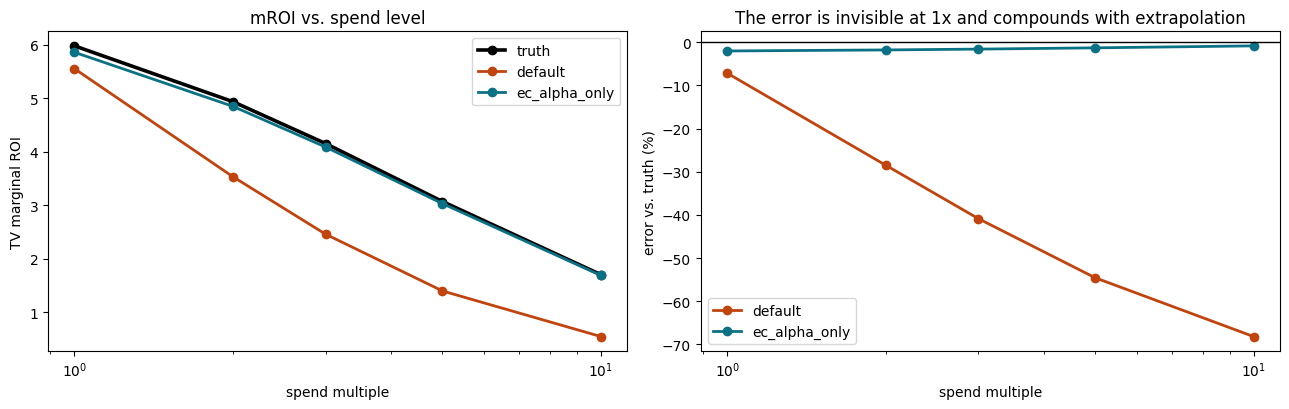

,spend_multiple,true_mroi,default,default_err_pct,ec_alpha_only,ec_alpha_only_err_pct
0,1x,5.977,5.550,-7.100000,5.857,-2.0
1,2x,4.933,3.529,-28.500000,4.846,-1.8
2,3x,4.150,2.455,-40.900002,4.084,-1.6
3,5x,3.066,1.394,-54.500000,3.027,-1.3
4,10x,1.698,0.540,-68.199997,1.684,-0.8


In [6]:
i_tv = channels.index('TV')
s = scen[PRIMARY]

params = {'truth': (float(s['true_ec'][i_tv]), float(s['true_alpha'][i_tv]),
                    s['sim'].beta_gm.numpy()[:, i_tv])}
for variant in VARIANTS:
  p = fitted[(PRIMARY, variant)].inference_data.posterior
  params[variant] = (float(p['ec_m'].values[..., i_tv].mean()),
                     float(p['alpha_m'].values[..., i_tv].mean()),
                     p['beta_gm'].values[..., i_tv].mean(axis=(0, 1)))

anchor_mroi = {'truth': truth_mroi['TV']}
for variant in VARIANTS:
  anchor_mroi[variant] = float(current_spend.query(
      'variant == @variant and channel == "TV"')['mroi'].iloc[0])


def mroi_curve(key):
  ec, al, bg = params[key]
  raw = []
  for mult in MULTIPLIERS:
    base = incremental(mult, ec, al, bg, i_tv)
    raw.append((incremental(mult * 1.01, ec, al, bg, i_tv) - base) / (0.01 * mult))
  scale = anchor_mroi[key] / raw[0]
  return [v * scale for v in raw]


curves = {k: mroi_curve(k) for k in ['truth'] + VARIANTS}
mroi_table = pd.DataFrame({
    'spend_multiple': [f'{m}x' for m in MULTIPLIERS],
    'true_mroi': np.round(curves['truth'], 3),
    'default': np.round(curves['default'], 3),
    'default_err_pct': np.round(
        [(d / t - 1) * 100 for d, t in zip(curves['default'], curves['truth'])], 1),
    'ec_alpha_only': np.round(curves['ec_alpha_only'], 3),
    'ec_alpha_only_err_pct': np.round(
        [(e / t - 1) * 100 for e, t in zip(curves['ec_alpha_only'], curves['truth'])], 1),
})
mroi_table.to_csv(os.path.join(OUT_DIR, f'{PRIMARY}_mroi_sweep.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for key, color, lw in [('truth', 'k', 2.6), ('default', '#c1440e', 2.0),
                       ('ec_alpha_only', '#0b7285', 2.0)]:
    axes[0].plot(MULTIPLIERS, curves[key], 'o-', color=color, lw=lw, label=key)
axes[0].set_xlabel('spend multiple'); axes[0].set_ylabel('TV marginal ROI')
axes[0].set_title('mROI vs. spend level'); axes[0].legend(); axes[0].set_xscale('log')
for key, color in [('default', '#c1440e'), ('ec_alpha_only', '#0b7285')]:
    axes[1].plot(MULTIPLIERS,
                 [(v / t - 1) * 100 for v, t in zip(curves[key], curves['truth'])],
                 'o-', color=color, lw=2.0, label=key)
axes[1].axhline(0, color='k', lw=1)
axes[1].set_xlabel('spend multiple'); axes[1].set_ylabel('error vs. truth (%)')
axes[1].set_title('The error is invisible at 1x and compounds with extrapolation')
axes[1].legend(); axes[1].set_xscale('log')
plt.tight_layout(); plt.show()

mroi_table

## 6. The invariance result: the default fit does not track the truth

Sections 3-5 establish that `default` gets `ec_m` badly wrong *in one scenario*.
A reasonable objection is that this is a property of the particular truth
chosen. This section answers it directly.

The two scenarios differ in exactly one respect -- TV's true `ec_m` -- and their
media execution is bit-identical (asserted in Section 1). So we can ask: **when
the truth moves, does the posterior follow?**

That is a stronger and more general claim than any single error percentage,
because it does not depend on which truth you picked. If the default posterior
were estimating `ec_m`, it would track. If it is reporting its prior with a
small likelihood nudge, it will not.

In [7]:
def fitted_ec_tv(tag, variant):
  p = fitted[(tag, variant)].inference_data.posterior
  return float(p['ec_m'].values[..., i_tv].mean())


rows = [{'source': 'TRUTH',
         COMPARISON: round(float(scen[COMPARISON]['true_ec'][i_tv]), 3),
         PRIMARY: round(float(scen[PRIMARY]['true_ec'][i_tv]), 3)}]
for variant in VARIANTS:
  rows.append({'source': variant,
               COMPARISON: round(fitted_ec_tv(COMPARISON, variant), 3),
               PRIMARY: round(fitted_ec_tv(PRIMARY, variant), 3)})

invariance = pd.DataFrame(rows)
invariance['pct_change'] = (
    (invariance[PRIMARY] / invariance[COMPARISON] - 1) * 100).round(1)
truth_move = float(invariance.loc[0, 'pct_change'])
invariance['tracks_truth'] = (
    invariance['pct_change'] / truth_move).round(2)
invariance.to_csv(os.path.join(OUT_DIR, 'invariance_table.csv'), index=False)

print(f'TV true ec_m moved {truth_move:+.1f}% between scenarios.')
for variant in VARIANTS:
  r = invariance.query('source == @variant').iloc[0]
  print(f'  {variant:14s} moved {r["pct_change"]:+6.1f}%  '
        f'-> absorbed {r["tracks_truth"]:.0%} of the change')
print('\n(`tracks_truth` = 1.0 means the fit followed the truth one-for-one;'
      ' 0.0 means it ignored it entirely.)')
invariance

TV true ec_m moved -18.7% between scenarios.
  default        moved   -1.3%  -> absorbed 7% of the change
  ec_alpha_only  moved  -18.5%  -> absorbed 99% of the change

(`tracks_truth` = 1.0 means the fit followed the truth one-for-one; 0.0 means it ignored it entirely.)


,source,ec11,ec9,pct_change,tracks_truth
0,TRUTH,11.069,9.000,-18.7,1.00
1,default,2.880,2.842,-1.3,0.07
2,ec_alpha_only,11.219,9.143,-18.5,0.99


**Read the `tracks_truth` column.** The informed prior follows the truth
almost exactly. The default absorbs only a small fraction of the same move --
its posterior lands in nearly the same place regardless of what generated the
data, because Section 2's prior concentration dominates the likelihood in this
regime.

This is the cleanest single demonstration in the study, and it is the one slide
that cannot be dismissed as a rigged choice of truth.

## 7. Which number to lead with

Ranked by how cleanly each separates `default` from the truth. Errors are read
from the tables above rather than restated here, so this ranking cannot go
stale:

| rank | metric | where to read it | verdict |
|---|---|---|---|
| 1 | **mROI at 3x spend** | Section 5 table | Sharpest, and it is literally the planner's question: what does my next dollar earn if I scale this up? |
| 2 | **`mROI / ROI` at current spend** | Section 4, `mroi_over_roi` | No extrapolation needed. `ec_m` in decision language. |
| 3 | `roi_m` | Section 4, `roi_err_pct` | Weak -- interval nearly touches truth. |
| 4 | mROI at current spend | Section 4, `mroi_err_pct` | **Least discriminating of the four. Do not lead with it** -- the ROI and elasticity errors partly cancel, so it can read as near-correct while the curve is badly wrong. |

`ec_m` stays the right slide for *what* goes wrong; mROI-at-elevated-spend is
the right slide for *so what*; Section 6's invariance table is the right slide
for *why you should believe it generalizes*.

**The framing this supports**, which is stronger and more honest than claiming
the default model gets ROI wrong:

> The default model's ROI looks fine. Its model summary looks fine. That is
> what makes the failure dangerous -- it is invisible in every standard
> diagnostic, and it surfaces only when you ask the question you built the
> model to answer: should I spend more here?

**Do not overclaim.** The defensible statement is *ROI can look fine while the
saturation curve is badly wrong*, never *ROI is reliably recovered*. In
lower-signal variants of this scenario the default's ROI error on other channels
runs far higher while still passing a 90% HDI coverage check, because a wide
interval covers the truth by construction. Coverage checkmarks reward
imprecision; pair any of them with point errors.

**Caveats.**
1. Single simulator draw at `SIM_SEED = 0`. The *ordering* of the metric ranking
   should be stable, since it follows from the `beta`/`ec` ridge rather than
   from any particular draw, but the magnitudes will move.
2. Section 5's figures are posterior-mean point estimates without credible
   intervals (see Section 5's note). This is the open item most likely to be
   challenged.
3. Section 6 compares two scenarios, not many; it establishes that the default
   ignores a 19% move in the truth, not a general elasticity.
4. All fits use `media_prior_type='roi'`, Meridian's default. The same scenario
   under `'coefficient'` reaches the same conclusions with uniformly *smaller*
   effects (see `fitted_models/mroi_metric_selection/`
   `roi-vs-mroi-metric-selection.ec9-coefficient-backup.ipynb`), so the results
   here are not an artifact of the parameterization -- but the magnitudes are
   parameterization-dependent and should be quoted as such.